In [2]:
def Poly(P, alpha):
    valeur = 0
    for i in range(len(P)):
        valeur += P[i] * (alpha**i)
    return valeur

P = [-3, 5, 2, 7, -2, 3] 
%time Poly(P, 1)

CPU times: user 17 μs, sys: 5 μs, total: 22 μs
Wall time: 25.3 μs


12

In [3]:
def Horner(P, alpha):
    n = len(P) - 1 
    A = P[n]      
    
    for j in range(n - 1, -1, -1):
        A = P[j] + alpha * A  
        
    return A

P = [-3, 5, 2, 7, -2, 3] 
%time Horner(P, 1)

CPU times: user 122 μs, sys: 33 μs, total: 155 μs
Wall time: 280 μs


12

In [4]:
def deriv(f, x, h=0.001):
    resultat = (f(x + h) - f(x)) / h
    return resultat

print(deriv(ln, 2.0)) 

0.499875041651054


In [ ]:
def deriv(f, x, h=0.001):
    return (f(x + h) - f(x)) / h

f = ln
x0 = 2.0
valeur_exacte = 0.5 

for p in range(1, 16):
    h = 10**(-p)
    valeur_approchee = deriv(f, x0, h)
    erreur = abs(valeur_approchee - valeur_exacte)      
    print(erreur)

0.0120983583056795
0.00124584889610269
0.000124958348945547
0.0000124995825352414
1.24998572564872e-6
1.24941223589303e-7
1.30307427070875e-8
3.03873548546107e-9
4.13701854995452e-8
4.13701854995452e-8
4.13701854995452e-8
0.0000444502911705058
0.000399638918679557
0.0107025913275720
0.0559107901499374


In [8]:
def deriv2(f, x, h):
    numerateur = f(x + h/2) - f(x - h/2)
    return numerateur / h


h = 10**(-8)
deriv2(ln, 2., h)


0.499999996961265

In [9]:
f(x) = 1/x
deriv2(f, 2., h)

-0.249999998480632

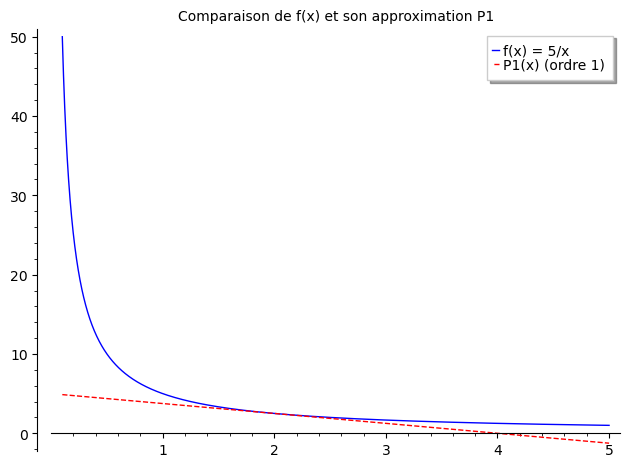

In [10]:
# 1.
f(x) = 5 / x
x0 = 2

f_prime = diff(f, x)
f_prime_x0 = f_prime(x = x0)
f_x0 = f(x = x0)

P1(x) = f_prime_x0 * (x - x0) + f_x0

graph_f = plot(f, (x, 0.1, 5), color='blue', legend_label='f(x) = 5/x')
graph_P1 = plot(P1, (x, 0.1, 5), color='red', linestyle='--', legend_label='P1(x) (ordre 1)')

show(graph_f + graph_P1, title="Comparaison de f(x) et son approximation P1")

In [11]:
# d0 désigne f(x0)
# d1 désigne f′(x0)
# d2 désigne f′′(x0)

a, b, c, x0, d0, d1, d2 = var('a, b, c, x0, d0, d1, d2')
solve([a*x0**2 + b*x0 +c == d0, 2*a*x0+ b==d1, 2*a==d2], a, b, c)

[[a == 1/2*d2, b == -d2*x0 + d1, c == 1/2*d2*x0^2 - d1*x0 + d0]]

In [12]:
def deriv_seconde(f, x, h=0.01):
    numerateur = f(x + h) - 2 * f(x) + f(x - h)
    denominateur = h**2
    
    return numerateur / denominateur

deriv_seconde(ln, 2.)

-0.250003125052967

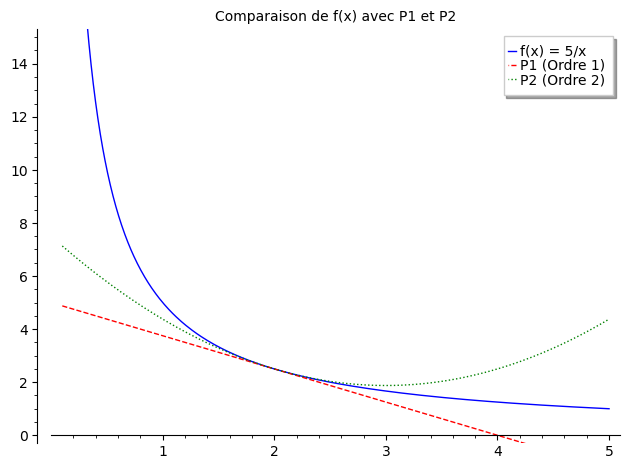

In [13]:
# 1
f(x) = 5 / x
x0 = 2

# Calcul des dérivées nécessaires
f1 = diff(f, x)        # Dérivée première
f2 = diff(f, x, 2)     # Dérivée seconde

# Définition des polynômes d'approximation
P1(x) = f(x0) + f1(x0)*(x - x0)
P2(x) = f(x0) + f1(x0)*(x - x0) + (f2(x0)/2)*(x - x0)^2

# Création des graphiques sur ]0; 5]
graph_f  = plot(f, (x, 0.1, 5), color='blue', legend_label='f(x) = 5/x')
graph_P1 = plot(P1, (x, 0.1, 5), color='red', linestyle='--', legend_label='P1 (Ordre 1)')
graph_P2 = plot(P2, (x, 0.1, 5), color='green', linestyle=':', legend_label='P2 (Ordre 2)')

# Affichage combiné
show(graph_f + graph_P1 + graph_P2, title="Comparaison de f(x) avec P1 et P2", ymin=0, ymax=15)

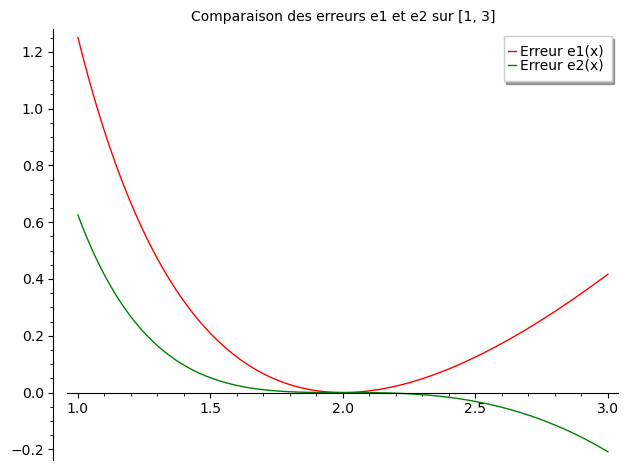

In [14]:
# 2. Définition des fonctions d'erreur
e1(x) = f(x) - P1(x)
e2(x) = f(x) - P2(x)

# Création du graphique des erreurs
graph_e1 = plot(e1, (x, 1, 3), color='red', legend_label='Erreur e1(x)')
graph_e2 = plot(e2, (x, 1, 3), color='green', legend_label='Erreur e2(x)')

# Affichage pour comparer la précision
show(graph_e1 + graph_e2, title="Comparaison des erreurs e1 et e2 sur [1, 3]")